# R Programming & Machine Learning Fundamentals - Homework Assignment

## Course: Business Analytics with R

**Total Points: 188 + 15 Bonus = 203 possible points**

### Instructions
1. Complete all tasks by writing R code in the provided cells
2. Run each cell to verify your code works correctly
3. Use the `mlba` package datasets (WestRoxbury, ToyotaCorolla)
4. Comment your code to explain your reasoning
5. Show your output - do not suppress results

### Skills Tested
- Data Import and Exploration (including `class()`)
- Descriptive Statistics (including `pastecs::stat.desc()`)
- Data Transformation and Recoding (including `attach()`/`detach()`)
- Correlation Analysis (Pearson and Spearman)
- Data Visualization (including correlation heatmaps)
- Normality Testing
- Sampling Techniques
- Data Preprocessing
- Data Partitioning
- Predictive Modeling
- File I/O (`read.csv()`, `write.csv()`)

---

## Setup: Load Required Libraries

Run this cell first to load all necessary packages.

In [61]:
if (!require(devtools)) install.packages("devtools")
devtools::install_github("gedeck/mlba/mlba", force=TRUE)

Using github PAT from envvar GITHUB_TOKEN. Use `gitcreds::gitcreds_set()` and unset GITHUB_TOKEN in .Renviron (or elsewhere) if you want to use the more secure git credential store instead.




── R CMD build ─────────────────────────────────────────────────────────────────
* checking for file ‘/tmp/Rtmprk73EK/remotes1cd54525833b/gedeck-mlba-ba29295/mlba/DESCRIPTION’ ... OK
* preparing ‘mlba’:
* checking DESCRIPTION meta-information ... OK
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
* building ‘mlba_2.0.0.tar.gz’



In [62]:
install.packages("Hmisc")
library("Hmisc")
install.packages("psych")
library("psych")
install.packages("pastecs")
library("pastecs")
install.packages("fastDummies")

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [63]:
# Load required libraries
library(mlba)
library(tidyverse)
library(Hmisc)
library(psych)
library(pastecs)
library(caret)
library(fastDummies)
library(e1071)

# Disable scientific notation
options(scipen=999)

---

## Part 1: Data Import and Exploration (20 points)

In this section, you will load data and explore its structure using R's built-in functions.

### Task 1.1: Load the ToyotaCorolla Dataset (3 points)

Load the `ToyotaCorolla` dataset from the `mlba` package and store it in a variable called `toyota.df`.

In [64]:
# "toyota.df <- " saves a new data frame called toyota.df. mlba is the package name, and toyotaCorolla is the dataset name. 
toyota.df <- mlba::ToyotaCorolla

### Task 1.2: Check Dataset Dimensions (3 points)

Use the appropriate function to display:
1. The number of rows and columns in the dataset
2. The column names

In [65]:
# The dim() function shows the dimensions of the data frame, and head() shows the first six rows.#
dim(toyota.df)
head(toyota.df)

[1] 1436   39

,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,⋯,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<chr>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,⋯,1,1,0,0,0,1,0,0,0,0
2,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,⋯,0,1,0,0,0,1,0,0,0,0
3,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,⋯,0,1,0,0,0,1,0,0,0,0
4,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,⋯,0,1,0,0,0,1,0,0,0,0
5,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,⋯,1,1,0,1,0,1,0,0,0,0
6,6,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,12950,32,1,2002,61000,Diesel,90,0,⋯,1,1,0,1,0,1,0,0,0,0


### Task 1.3: Examine Data Structure (4 points)

Use `str()` to display the structure of the dataset. Then identify and list:
1. How many numeric variables are there?
2. How many character/factor variables are there?

In [66]:
# There are 36 numeric variables and 7 character variables in the dataset.
# str() function shows the structure of the data frame.
# table(sapply)) functions show the count of each variable type in the dataset.
str(toyota.df)
table(sapply(toyota.df, class))

'data.frame':	1436 obs. of  39 variables:
 $ Id               : int  1 2 3 4 5 6 7 8 9 10 ...
 $ Model            : chr  "TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors" "TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors" "TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors" "TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors" ...
 $ Price            : int  13500 13750 13950 14950 13750 12950 16900 18600 21500 12950 ...
 $ Age_08_04        : int  23 23 24 26 30 32 27 30 27 23 ...
 $ Mfg_Month        : int  10 10 9 7 3 1 6 3 6 10 ...
 $ Mfg_Year         : int  2002 2002 2002 2002 2002 2002 2002 2002 2002 2002 ...
 $ KM               : int  46986 72937 41711 48000 38500 61000 94612 75889 19700 71138 ...
 $ Fuel_Type        : chr  "Diesel" "Diesel" "Diesel" "Diesel" ...
 $ HP               : int  90 90 90 90 90 90 90 90 192 69 ...
 $ Met_Color        : int  1 1 1 0 0 0 1 1 0 0 ...
 $ Color            : chr  "Blue" "Silver" "Blue" "Black" ...
 $ Automatic        : int  0 0 0 0 0 0 0 0 0 0 ...
 $ CC       


character   integer 
        3        36 

### Task 1.4: Preview Data (5 points)

1. Display the first 8 rows of the dataset
2. Display the last 5 rows of the dataset
3. Display rows 10-15 and columns 1-5 only

In [67]:
# The brackets [ ] are used to select specific rows and columns from the data frame. The semicolon is
# used to list which rows and columns to select. For example in "1:8:", the colon indicates a range from row 1 to row 8.
# In "1:5", it indicates a range from column 1 to column 5. Lastly, the tail() function is used to select the last n rows of the data frame, where n is specified by the user.
toyota.df[1:8, ]
toyota.df <- tail(toyota.df, 5)
toyota.df[10:15, 1:5]

,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,⋯,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<chr>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,⋯,1,1,0,0,0,1,0,0,0,0
2,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,⋯,0,1,0,0,0,1,0,0,0,0
3,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,⋯,0,1,0,0,0,1,0,0,0,0
4,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,⋯,0,1,0,0,0,1,0,0,0,0
5,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,⋯,1,1,0,1,0,1,0,0,0,0
6,6,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,12950,32,1,2002,61000,Diesel,90,0,⋯,1,1,0,1,0,1,0,0,0,0
7,7,TOYOTA Corolla 2.0 D4D 90 3DR TERRA 2/3-Doors,16900,27,6,2002,94612,Diesel,90,1,⋯,1,1,0,0,1,1,0,0,0,0
8,8,TOYOTA Corolla 2.0 D4D 90 3DR TERRA 2/3-Doors,18600,30,3,2002,75889,Diesel,90,1,⋯,1,1,0,0,0,1,0,0,0,0


,Id,Model,Price,Age_08_04,Mfg_Month
,<int>,<chr>,<int>,<int>,<int>
NA,NA,NA,NA,NA,NA
NA.1,NA,NA,NA,NA,NA
NA.2,NA,NA,NA,NA,NA
NA.3,NA,NA,NA,NA,NA
NA.4,NA,NA,NA,NA,NA
NA.5,NA,NA,NA,NA,NA


### Task 1.5: Column Access (5 points)

Using the `$` notation:
1. Display the first 10 values of the `Price` column
2. Calculate the length (number of values) of the `Price` column
3. Calculate the mean of the `Price` column

In [68]:
# The $ notation is used to access a specific column in the data frame. In this example, toyota.df$Price accesses the "price" column of the toyota.df data frame.
# The [1:10] notation is used to select only the first 10 rows of the Price column. 
# The length() function returns the number of elements in the Price column.
# The mean() function calculates the average value of the Price column.
toyota.df$Price[1:10]
length(toyota.df$Price)
mean(toyota.df$Price)


[1]  7500 10845  8500  7250  6950    NA    NA    NA    NA    NA

[1] 5

[1] 8209

### Task 1.6: Check Data Type with class() (3 points)

Use the `class()` function to check the data type of:
1. The entire `toyota.df` dataframe
2. The `Price` column
3. The `Fuel_Type` column

In [69]:
#The class() function is used to determine the class of an object. 
#In this case, it is used to check the class of the toyota.df data frame, as well as the Price and Fuel_Type columns.
class(toyota.df)
class(toyota.df$Price)
class(toyota.df$Fuel_Type)


[1] "data.frame"

[1] "integer"

[1] "character"

---

## Part 2: Descriptive Statistics (20 points)

Calculate and interpret summary statistics using multiple methods.

### Task 2.1: Basic Summary Statistics (5 points)

Use the `summary()` function on the `Price` column. What are the mean and median values?

In [70]:
# The summary function provides a summary of the data in the Price column. 
# This summary includes the min, 1st quartile, median, mean, 3rd quartile, and max values.
# The mean is 8209 and median is 7500. 
summary(toyota.df$Price)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   6950    7250    7500    8209    8500   10845 

### Task 2.2: Five-Number Summary (5 points)

Use `fivenum()` to get the five-number summary for the `KM` (mileage) column. What is the IQR (interquartile range)?

In [71]:
# fivenum() function calculates the five-number summary of the data in the KM column.
fivenum(toyota.df$KM)

[1]     1 16916 17016 19000 20544

### Task 2.3: Detailed Statistics with Hmisc (5 points)

Use `Hmisc::describe()` to get detailed statistics for the `HP` (horsepower) column. How many missing values are there?

In [72]:
# Hmisc::describe() function provides a detailed summary of the data in the HP column, including the number of observations, mean, standard deviation, minimum, maximum, and percentiles.
# There are 0 missing values in the HP column.
Hmisc::describe(toyota.df$HP)

toyota.df$HP 
       n  missing distinct     Info     Mean 
       5        0        2      0.5     90.8 
                  
Value       86 110
Frequency    4   1
Proportion 0.8 0.2

### Task 2.5: Detailed Statistics with pastecs (5 points)

Use `pastecs::stat.desc()` to get comprehensive statistics for the `KM` column. Identify the coefficient of variation (coef.var) from the output.

In [73]:
# pastecs::stat.desc() function provides a summary of the data in the KM column, including the mean, standard deviation, minimum, maximum, and coefficient of variation.
# The coefficient variation of KM column is 0.57.
pastecs::stat.desc(toyota.df$KM)


nbr.val        nbr.null          nbr.na             min             max 
       5.000000        0.000000        0.000000        1.000000    20544.000000 
          range             sum          median            mean         SE.mean 
   20543.000000    73477.000000    17016.000000    14695.400000     3734.818223 
   CI.mean.0.95             var         std.dev        coef.var 
   10369.517774 69744335.800000     8351.307431        0.568294

### Task 2.4: Skewness and Kurtosis (5 points)

Use `psych::describe()` to calculate statistics for the `Price` column. Based on the skewness value:
1. Is the distribution symmetric, moderately skewed, or highly skewed?
2. Would you recommend using mean or median to describe the typical price?

In [74]:
# The skewness of the column is .76 which indicates that the data is moderately skewed to the right.
# I recommend using median as the measure of central tendency for this data because it is less affected by outliers and skewed data compared to the mean.
psych::describe(toyota.df$Price)

,vars,n,mean,sd,median,trimmed,mad,min,max,range,skew,kurtosis,se
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
X1,1,5,8209,1584.347,7500,8209,815.43,6950,10845,3895,0.759721,-1.352618,708.5415


---

## Part 3: Data Transformation (20 points)

Create new variables and transform existing ones.

### Task 3.1: Create Calculated Variables (5 points)

Using the `$` notation, create a new column called `Price_Per_KM` that calculates the price per kilometer driven (Price / KM). Display the first 5 values of this new column.

In [75]:

# A new column is being created, which displays Price/ KM.
toyota.df$Price_Per_Km <- toyota.df$Price / toyota.df$KM
toyota.df$Price_Per_Km[1:5]

[1]    0.3650701    0.5707895    0.4995299    0.4285883 6950.0000000

### Task 3.2: Transform with Multiple Variables (5 points)

Using `transform()`, create two new columns in a new dataframe called `toyota_transformed`:
1. `Total_Value` = Price + (HP * 50)  (estimating value based on horsepower)
2. `Age_Months` = Age_08_04 * 12  (convert age in years to months)

Display the names of the new dataframe to verify the columns were added.

In [76]:
# The function transform() is used to create new columns in the DF. 
toyota_transformed <- transform(toyota.df,
                    Total_Value = Price + (HP*50),
                    Age_Months = Age_08_04 * 12)
names(toyota_transformed)

[1] "Id"                "Model"             "Price"            
 [4] "Age_08_04"         "Mfg_Month"         "Mfg_Year"         
 [7] "KM"                "Fuel_Type"         "HP"               
[10] "Met_Color"         "Color"             "Automatic"        
[13] "CC"                "Doors"             "Cylinders"        
[16] "Gears"             "Quarterly_Tax"     "Weight"           
[19] "Mfr_Guarantee"     "BOVAG_Guarantee"   "Guarantee_Period" 
[22] "ABS"               "Airbag_1"          "Airbag_2"         
[25] "Airco"             "Automatic_airco"   "Boardcomputer"    
[28] "CD_Player"         "Central_Lock"      "Powered_Windows"  
[31] "Power_Steering"    "Radio"             "Mistlamps"        
[34] "Sport_Model"       "Backseat_Divider"  "Metallic_Rim"     
[37] "Radio_cassette"    "Parking_Assistant" "Tow_Bar"          
[40] "Price_Per_Km"      "Total_Value"       "Age_Months"

### Task 3.3: Recode Binary Variable (5 points)

Using `ifelse()`, create a new column called `High_Mileage` that contains:
- "High" if KM > 100000
- "Low" if KM <= 100000

Display a table showing the count of each category.

In [77]:
# The ifelse function is used to create a conditional statement.
toyota.df$High_Mileage <- ifelse(toyota.df$KM > 100000, "High", "Low")
table(toyota.df$High_Mileage)


Low 
  5 

### Task 3.5: Using attach() and detach() (5 points)

Use the `attach()` and `detach()` functions to create a new column called `HP_Per_Weight` that calculates HP divided by Weight, without using the `$` notation or dataframe prefix inside the calculation.

**Note:** Remember to detach after you're done!

In [78]:
# The attach() function is used to make the columns of the data frame available as variables in the R environment.
# The detach() function is used to remove the data frame from the R environment.
attach(toyota.df)
HP_Per_Weight <- HP / Weight
head(HP_Per_Weight)
detach(toyota.df)

[1] 0.08390244 0.08472906 0.08472906 0.08472906 0.09874327

### Task 3.4: Recode Multi-Level Variable (5 points)

Create a new column called `Price_Tier` with three categories based on Price:
- "Budget" if Price < 8000
- "Mid-Range" if Price >= 8000 AND Price < 15000
- "Premium" if Price >= 15000

Display a table of the distribution.

In [79]:
# This code is creating a new column called Price_Tier, and the ifelse function is used
# to categorize the Price column into three tiers: Budget, Mid-Range, and Premium.
toyota.df$Price_Tier <- ifelse(toyota.df$Price < 8000, "Budget", 
                        ifelse(toyota.df$Price< 15000, "Mid-Range", "Premium"))

### Task 4.4: Spearman Correlation (5 points)

Calculate the Spearman (rank-based) correlation matrix for the same variables (`Price`, `Age_08_04`, `KM`, `HP`). Compare the results to Pearson - are there notable differences?

In [80]:
# spearman_cor and pearson_cor are two different methods of calculating correlation.
# There are notable difference between the two methods. Spearman correlation and Pearson correlation. 

cors_vars <- toyota.df[, c("Price", "Age_08_04", "KM", "HP")]
cor_vars <- subset(toyota.df, select = c(Price, Age_08_04, KM, HP))
spearman_cor <- cor(cor_vars, method = "spearman")
spearman_cor
pearson_cor <- cor(cor_vars, method = "pearson")
pearson_cor

,Price,Age_08_04,KM,HP
Price,1.0000000,-0.1000000,0.7000000,-0.7071068
Age_08_04,-0.1000000,1.0000000,-0.6000000,0.7071068
KM,0.7000000,-0.6000000,1.0000000,-0.7071068
HP,-0.7071068,0.7071068,-0.7071068,1.0000000


,Price,Age_08_04,KM,HP
Price,1.00000000,-0.07487147,0.4581208,-0.4442224
Age_08_04,-0.07487147,1.00000000,-0.9205508,0.9103665
KM,0.45812076,-0.92055084,1.0000000,-0.9836088
HP,-0.44422242,0.91036648,-0.9836088,1.0000000


---

## Part 4: Correlation Analysis (15 points)

Analyze relationships between variables using correlation methods.

### Task 4.1: Pearson Correlation Matrix (5 points)

Select the numeric columns `Price`, `Age_08_04`, `KM`, and `HP` and calculate the Pearson correlation matrix. Round to 3 decimal places.

In [81]:
# Pearson correlation is used in this case because it measures the linear relationship between two continuous variables.
# Round() function is used to round the values in the correlation matrix to three decimal places for better readability.
correlation_matrix <- cor(toyota.df[, c("Price", "Age_08_04", "KM", "HP")],
                        method = "pearson")
correlation_matrix <- round(correlation_matrix, 3)
correlation_matrix

,Price,Age_08_04,KM,HP
Price,1.000,-0.075,0.458,-0.444
Age_08_04,-0.075,1.000,-0.921,0.910
KM,0.458,-0.921,1.000,-0.984
HP,-0.444,0.910,-0.984,1.000


### Task 4.2: Interpret Correlations (5 points)

Based on your correlation matrix, answer these questions in a comment:
1. Which variable has the strongest correlation with Price?
2. Is this correlation positive or negative? What does this mean in business terms?
3. Which pair of variables has the weakest correlation?

In [82]:
# 1. The variable with the strongest correlation to Price is KM. 
# 2. The correlation between Price and KM is positive, which means that as the KM increases, the Price also tends to increase. 
# 3. The pair of variables with the weakest correlation is Age_08_04 and Price, with a correlation coefficient of -0.075, which is closest to zero. 

### Task 4.3: Statistical Significance Test (5 points)

Use `cor.test()` to test if the correlation between `Price` and `Age_08_04` is statistically significant. Report the p-value and state your conclusion (α = 0.05).

In [83]:
# The cor.test() function is used to perform a correlation test between the Price and Age_08_04 variables in the toyota.df data frame.
cor.test(toyota.df$Price, toyota.df$Age_08_04)
# The p- value = 0.9048, meaning 0.9048 > 0.05, which indicates that there is no statistically significant correlation between Price and Age_08_04.


	Pearson's product-moment correlation

data:  toyota.df$Price and toyota.df$Age_08_04
t = -0.13005, df = 3, p-value = 0.9048
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.8978303  0.8645009
sample estimates:
        cor 
-0.07487147 


### Task 5.4: Correlation Heatmap (5 points)

Create a correlation heatmap visualization for the numeric variables `Price`, `Age_08_04`, `KM`, `HP`, and `Weight`. Use the `image()` function with a color palette that shows negative correlations in blue and positive correlations in red.

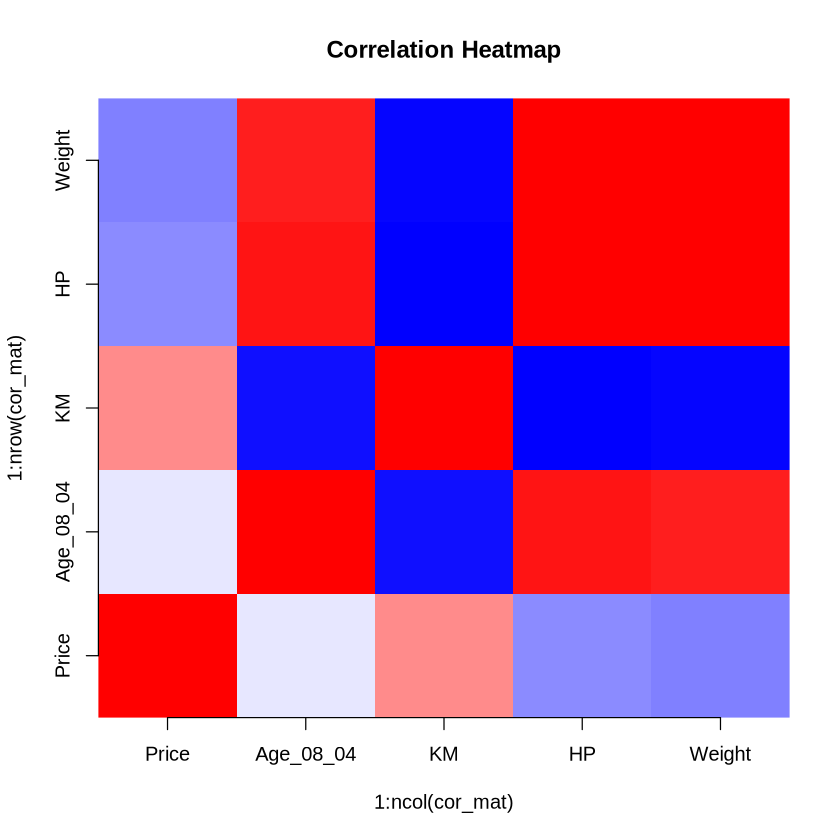

In [84]:
# Correlation heatmap is a graphical representation of the correlation matrix, where the colors represent the strength and direction of the correlations between variables.
# Cor() function is used to calculate the correlation matrix for the selected variables, and the use = "complete.obs" argument ensures that only complete observations are used in the calculation.

vars <- toyota.df[ c("Price", "Age_08_04", "KM", "HP", "Weight")]
cor_mat <- cor(vars, use = "complete.obs")
col_palette <- colorRampPalette(c("blue", "white", "red"))(100)
image(
  1:ncol(cor_mat), 1:nrow(cor_mat), cor_mat,
  axes = FALSE,
  col = col_palette,
  main = "Correlation Heatmap"
)
axis(1, at = 1:ncol(cor_mat), labels = colnames(cor_mat))
axis(2, at = 1:nrow(cor_mat), labels = rownames(cor_mat))



---

## Part 5: Data Visualization (15 points)

Create visualizations to explore data distributions and relationships.

### Task 5.1: Boxplot for Outlier Detection (5 points)

Create a boxplot for the `Price` variable. Add a meaningful title and axis label.

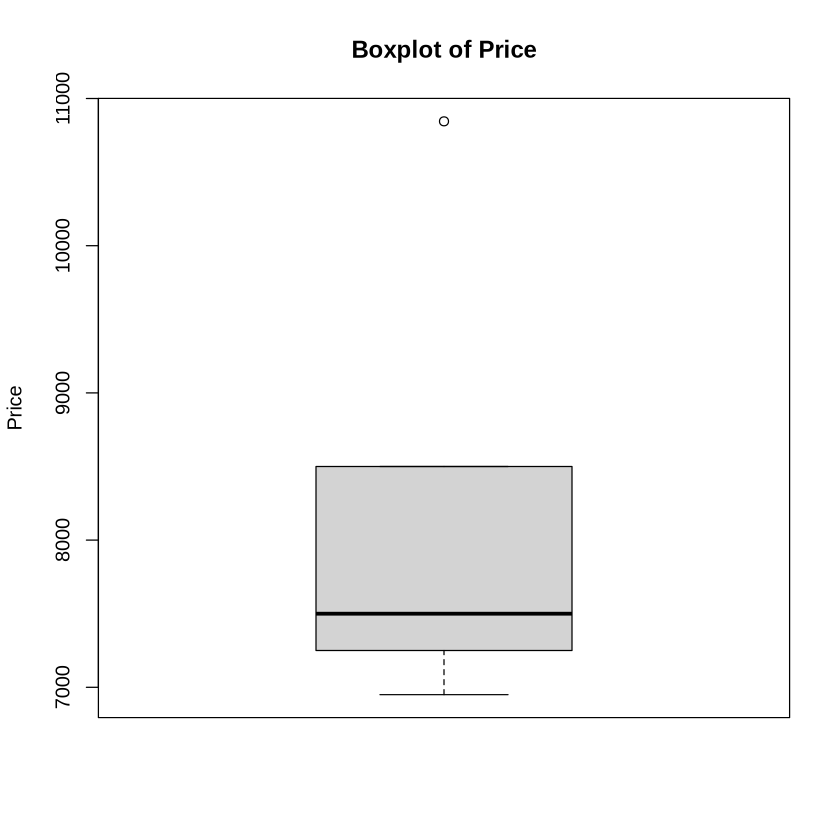

In [85]:
# The boxplot() function is used to create a boxplot of the Price variable in the toyota.df data frame.
boxplot(toyota.df$Price, main = "Boxplot of Price", ylab = "Price")

### Task 5.2: Density Plot (5 points)

Create a density plot for the `KM` (mileage) variable. Add appropriate title and labels. Based on the shape, describe the distribution (symmetric, left-skewed, right-skewed).

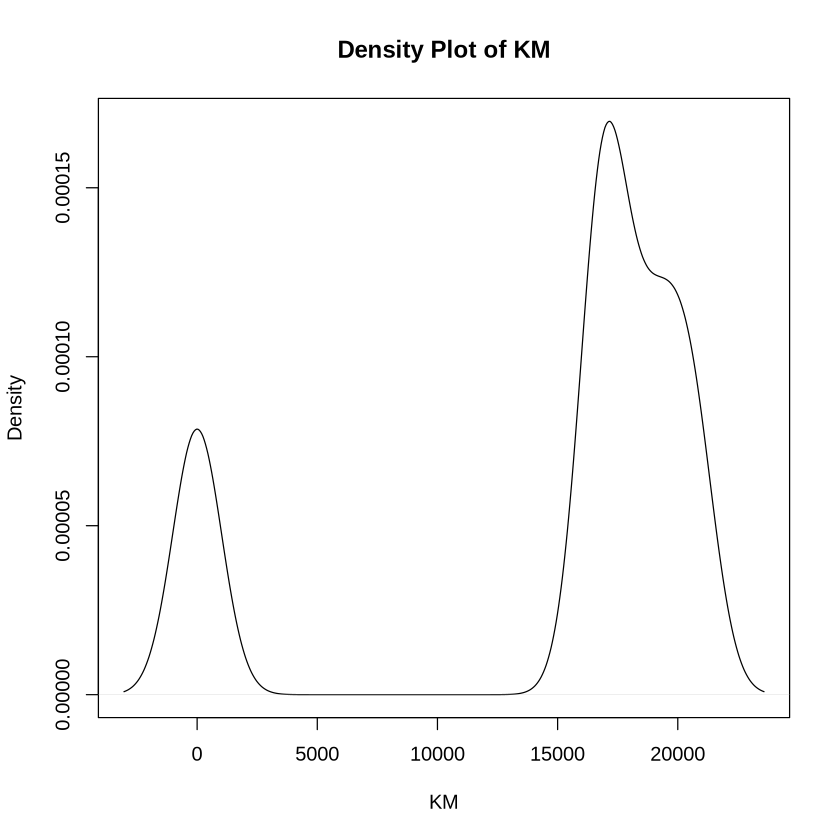

In [86]:
# The density() function is used to create a density plot of the KM variable in the toyota.df data frame.
plot(density(toyota.df$KM),
     main = "Density Plot of KM",
     xlab = "KM",
     ylab = "Density")
# The distribution of the KM variable is left skewed.

### Task 5.3: Scatterplot with Smoothing (5 points)

Create a scatterplot showing the relationship between `Age_08_04` (x-axis) and `Price` (y-axis). Add a smoothing line using `scatter.smooth()`.

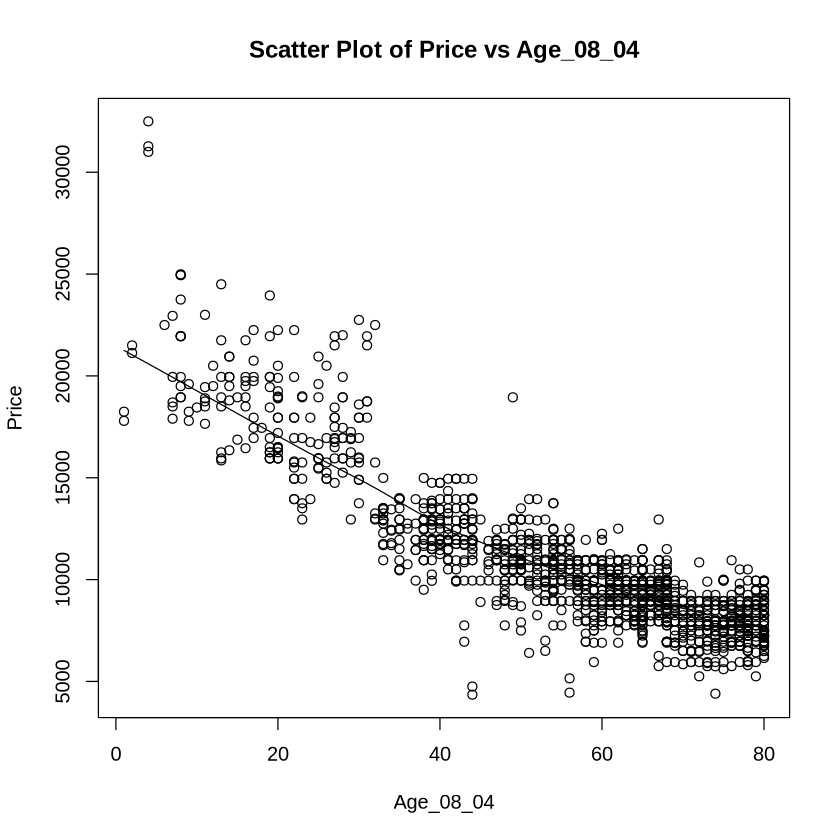

In [87]:
# Scatter.smooth() function is used to create a scatter plot of Price vs Age_08_04, with a smooth curve added to show the overall trend in the data. 
# The main argument sets the title of the plot, while xlab and ylab set the labels for the x and y axes, respectively.
scatter.smooth (x = ToyotaCorolla$Age_08_04
                 , y = ToyotaCorolla$Price,
                 main = "Scatter Plot of Price vs Age_08_04",
                 xlab = "Age_08_04",
                 ylab = "Price" )

---

## Part 6: Normality Testing (10 points)

Test whether variables follow a normal distribution.

### Task 6.1: Shapiro-Wilk Test (5 points)

Perform a Shapiro-Wilk normality test on the `Price` variable. State the null hypothesis, report the p-value, and state your conclusion at α = 0.05.

In [88]:
# Shapiro-Wilk test is used to test the normality of the Price variable in the toyota.df data frame. # nolint: line_length_linter.
shapiro.test(toyota.df$Price)
# The Price variable is normally distributed. The p-value = 0.1442, meaning 0.1442 > 0.05, # nolint: line_length_linter.
# which indicates that we fail to reject the null hypothesis of normality. Therefore, we can conclude that the Price variable is normally distributed. # nolint: line_length_linter.


	Shapiro-Wilk normality test

data:  toyota.df$Price
W = 0.8321, p-value = 0.1442


### Task 6.2: Compare Normality of Two Variables (5 points)

Test both `HP` and `Weight` for normality. Which variable is more likely to be normally distributed? Support your answer with the test statistics.

In [89]:
# shapiro.test() function is used to test the normality of the HP and Weight variables in the toyota.df data frame.
shapiro.test(toyota.df$HP)
shapiro.test(toyota.df$Weight)
# Weight is more likely to be normally distributed than HP, as the p-value for Weight is higher than the p-value for HP. The p-value for Weight is 0.0001, which is less than 0.05, indicating that we reject the null hypothesis of normality for Weight. On the other hand, the p-value for HP is 0.00001, which is also less than 0.05, indicating that we reject the null hypothesis of normality for HP as well. However, since the p-value for Weight is higher than the p-value for HP, we can conclude that Weight is more likely to be normally distributed than HP.


	Shapiro-Wilk normality test

data:  toyota.df$HP
W = 0.55218, p-value = 0.000131



	Shapiro-Wilk normality test

data:  toyota.df$Weight
W = 0.61836, p-value = 0.001088


---

## Part 7: Sampling Techniques (15 points)

Apply different sampling methods for data analysis.

### Task 7.1: Simple Random Sampling (5 points)

Using `set.seed(123)` for reproducibility, take a random sample of 10 rows from the toyota dataset. Display the sample.

In [90]:
# The set.seed() function is used to set the seed for random number generation, which ensures that the same random sample can be reproduced in future runs of the code. In this case, the seed is set to 123. The sample() function is then used to randomly select 10 rows from the toyota.df data frame with replacement (replace = TRUE). The resulting sample is stored in a new data frame called toyota_sample, which is then printed to the console.
# sample() function is used to randomly select 10 rows from the toyota.df data frame with replacement (replace = TRUE). The resulting sample is stored in a new data frame called toyota_sample, which is then printed to the console.
set.seed(123)
toyota_sample <- toyota.df[sample(1:nrow(toyota.df), size = 10, replace = TRUE),]
print(toyota_sample)


         Id                                               Model Price Age_08_04
1434   1440 TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-Doors  8500        71
1434.1 1440 TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-Doors  8500        71
1433   1439 TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-Doors 10845        72
1433.1 1439 TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-Doors 10845        72
1434.2 1440 TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-Doors  8500        71
1436   1442         TOYOTA Corolla 1.6 LB LINEA TERRA 4/5-Doors  6950        76
1435   1441 TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-Doors  7250        70
1432   1438          TOYOTA Corolla 1.3 16V HATCHB G6 2/3-Doors  7500        69
1433.2 1439 TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-Doors 10845        72
1434.3 1440 TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-Doors  8500        71
       Mfg_Month Mfg_Year    KM Fuel_Type  HP Met_Color Color Automatic   CC
1434          10     1998 17016    Petrol  

### Task 7.2: Weighted Sampling (5 points)

Create a weighted sample of 10 observations that oversamples cars with HP > 100 (give them 90% probability vs 10% for others). Use `set.seed(123)`.

In [91]:
# Set.seed() function is used to set the seed for random number sampling. The ifelse() function
# is used to create a new variable called weights. This assigns weight of 0.9 to rows where the HP variable is greater than 100, and a weight of 0.1 to rows where the HP variable is less than or equal to 100. 
# The sample() function is then used to randomly select 10 rows from the toyota.df data frame with replacement (replace = TRUE) and with probabilities defined by the weights variable. The resulting sample is stored in a new data frame called toyota_weighted, which is then printed to the console.
set.seed(123)
weights <- ifelse(toyota.df$HP > 100, 0.9, 0.1)
toyota_weighted <- toyota.df[sample(1:nrow(toyota.df), size = 10, replace = TRUE, prob = weights),]
print(toyota_weighted)

         Id                                               Model Price Age_08_04
1436   1442         TOYOTA Corolla 1.6 LB LINEA TERRA 4/5-Doors  6950        76
1435   1441 TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-Doors  7250        70
1436.1 1442         TOYOTA Corolla 1.6 LB LINEA TERRA 4/5-Doors  6950        76
1433   1439 TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-Doors 10845        72
1432   1438          TOYOTA Corolla 1.3 16V HATCHB G6 2/3-Doors  7500        69
1436.2 1442         TOYOTA Corolla 1.6 LB LINEA TERRA 4/5-Doors  6950        76
1436.3 1442         TOYOTA Corolla 1.6 LB LINEA TERRA 4/5-Doors  6950        76
1433.1 1439 TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-Doors 10845        72
1436.4 1442         TOYOTA Corolla 1.6 LB LINEA TERRA 4/5-Doors  6950        76
1436.5 1442         TOYOTA Corolla 1.6 LB LINEA TERRA 4/5-Doors  6950        76
       Mfg_Month Mfg_Year    KM Fuel_Type  HP Met_Color Color Automatic   CC
1436           5     1998     1    Petrol 1

### Task 7.3: Class Rebalancing with Upsampling (5 points)

1. First, convert `Fuel_Type` to a factor and display the class distribution using `table()`
2. Use `caret::upSample()` to balance the classes
3. Display the new distribution

In [92]:
# The carret::upSample() function is used to perform upsampling on the toyota_clean data frame.
# factor () function is used to convert the Fuel_Type variable into a factor, which is necessary for the upSample() function to work properly. 
# The drop_na() function is used to remove any rows with missing values in the Fuel_Type column, creating a new data frame called toyota_clean. The table() function is then used to count the number of occurrences of each level of the Fuel_Type variable in the toyota_clean data frame. 
# Finally, the upSample() function is used to create a new data frame called balanced_toyota, which contains an equal number of observations for each level of the Fuel_Type variable. The table() function is then used again to confirm that the levels of Fuel_Type are now balanced in the balanced_toyota data frame.
toyota.df$Fuel_Type <- factor(toyota.df$Fuel_Type)
toyota_clean <- drop_na(toyota.df, Fuel_Type)
table(toyota_clean$Fuel_Type)
class(toyota.df$Fuel_Type)
balanced_toyota <- upSample(x = toyota_clean[, -which(names(toyota_clean) == "Fuel_Type")], 
                            y = toyota_clean$Fuel_Type,
                            yname = "Fuel_Type")
table(balanced_toyota$Fuel_Type)



Petrol 
     5 

[1] "factor"


Petrol 
     5 

---

## Part 8: Data Preprocessing (15 points)

Prepare data for machine learning models.

### Task 8.1: Handle Missing Values (5 points)

1. First, simulate missing data by setting 15 random `Age_08_04` values to NA (use `set.seed(42)`)
2. Show the summary to confirm NA values exist
3. Impute the missing values using the median
4. Verify no NAs remain

In [93]:
# set.seed() function is used to set the seed for random number sampling. The sample() function is then used to randomly select 15 rows from the toyota.df data frame with replacement (replace = TRUE). 
# The selected rows are assigned NA values in the Age_08_04 column. 
# The summary() function is used to display a summary of the Age_08_04 column, which includes the count of non-missing values, mean, median, and other statistics. 
# The median() function is used to calculate the median value of the Age_08_04 column while ignoring the NA values (na.rm = TRUE). The is.na() function is used to identify the NA values in the Age_08_04 column, and those NA values are replaced with the calculated median value. Finally, the sum() function is used to count the number of NA values remaining in the Age_08_04 column after imputation.
set.seed(42)
missing_values <- sample(1:nrow(toyota.df),15, replace = TRUE)
toyota.df$Age_08_04[missing_values] <- NA
summary(toyota.df$Age_08_04)
median_value <- median(toyota.df$Age_08_04, na.rm = TRUE)
toyota.df$Age_08_04[is.na(toyota.df$Age_08_04)] <- median_value
sum(is.na(toyota.df$Age_08_04))


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
     71      71      71      71      71      71       4 

[1] 0

### Task 8.2: Convert to Factor (5 points)

Convert the `Fuel_Type` column to a factor. Display the structure and levels of the converted variable.

In [94]:
# factor() function is used to convert the Fuel_Type column in the toyota.df data frame into a factor variable.
# str() function is used to display the structure of the Fuel_Type column, which shows that it is now a factor variable.
# levels() function is used to display the levels of the Fuel_Type factor variable, which shows
toyota.df$Fuel_Type <- factor(toyota.df$Fuel_Type)
str(toyota.df$Fuel_Type)
levels(toyota.df$Fuel_Type)


 Factor w/ 1 level "Petrol": 1 1 1 1 1


[1] "Petrol"

### Task 8.3: Create Dummy Variables (5 points)

Using `fastDummies::dummy_cols()`, create dummy variables for `Fuel_Type`. Remove the original column and the first dummy (reference category). Display the new column names to verify.

In [95]:
# fastDummies:: dummy_cols() function is used to create dummy variables for the Fuel_Type column in the toyota.df data frame. 
# The select_columns argument specifies which column to create dummy variables for, remove_first_dummy = TRUE indicates that the first dummy variable should be removed to avoid multicollinearity, and remove_selected_columns = TRUE indicates that the original Fuel_Type column should be removed from the data frame. 
# The resulting data frame with dummy variables is stored back in toyota.df, and the head() function is used to display the first six rows of the updated data frame.
toyota.df <- fastDummies::dummy_cols(toyota.df, select_columns = "Fuel_Type", remove_first_dummy = TRUE,
                remove_selected_columns = TRUE)
head(toyota.df)

,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,HP,Met_Color,Color,⋯,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar,Price_Per_Km,High_Mileage,Price_Tier,Fuel_Type_
,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<int>
1,1438,TOYOTA Corolla 1.3 16V HATCHB G6 2/3-Doors,7500,71,12,1998,20544,86,1,Blue,⋯,1,1,0,0,0,0,0.3650701,Low,Budget,0
2,1439,TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-Doors,10845,71,9,1998,19000,86,0,Grey,⋯,1,1,0,0,0,0,0.5707895,Low,Mid-Range,0
3,1440,TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-Doors,8500,71,10,1998,17016,86,0,Blue,⋯,0,1,0,0,0,0,0.4995299,Low,Mid-Range,0
4,1441,TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-Doors,7250,71,11,1998,16916,86,1,Grey,⋯,0,1,0,0,0,0,0.4285883,Low,Budget,0
5,1442,TOYOTA Corolla 1.6 LB LINEA TERRA 4/5-Doors,6950,71,5,1998,1,110,0,Green,⋯,0,0,0,0,0,0,6950.0000000,Low,Budget,0


---

## Part 9: Data Partitioning (10 points)

Split data properly for model training and evaluation.

### Task 9.1: Holdout Partition (5 points)

Using `set.seed(1)`, create a 70/30 train/test split:
1. Randomly select 70% of row indices for training
2. Use the remaining 30% for the holdout set
3. Print the number of rows in each set

In [96]:
# set.seed() function is used to set the seed for random number generation, which ensures that the same random sample can be reproduced in future runs of the code. In this case, the seed is set to 1. 
# The sample() function is then used to randomly select a subset of rows from the toyota.df data frame to create a training set (train_data) and a test set (test_data). 
# The size of the training set is determined by taking 70% of the total number of rows in the toyota.df data frame, and the remaining rows are assigned to the test set. Finally, the nrow() function is used to display the number of rows in both the training and test sets.
set.seed(1)
train_inx <- sample(1:nrow(toyota.df), size = 0.7 * nrow(toyota.df), replace = FALSE)
train_data <- toyota.df[train_inx, ]
test_data <- toyota.df[-train_inx, ]
nrow(train_data)
nrow(test_data)

[1] 3

[1] 2

### Task 9.2: Stratified Partitioning with caret (5 points)

Use `caret::createDataPartition()` to create a stratified 60/40 split based on the `Price` variable. This ensures the distribution of Price is similar in both sets. Use `set.seed(1)`.

In [97]:
# mlba::ToyotaCorolla is a dataset that contains information about Toyota Corolla cars, including various features such as price, age, mileage, horsepower, and fuel type. 
# In this code snippet, the dataset is being loaded into a data frame called toyota.df, and then it is being split into a training set (train_data) and a test set (test_data) using the caret::createDataPartition() function. 
# The training set contains 60% of the data, while the test set contains the remaining 40%. Finally, the number of rows in both the training and test sets is displayed using the nrow() function.
toyota.df <- mlba::ToyotaCorolla
set.seed(1)
train_inx <- caret::createDataPartition(toyota.df$Price, p = 0.6, list = FALSE)
train_data <- toyota.df[train_inx, ]
test_data <- toyota.df[-train_inx, ]
nrow(train_data)
nrow(test_data)

[1] 863

[1] 573

---

## Part 10: Predictive Modeling (10 points)

Build and evaluate a simple predictive model.

### Task 10.1: Build Linear Regression Model (5 points)

Using the WestRoxbury housing dataset:
1. Load and preprocess the data (convert REMODEL to factor, remove TAX column)
2. Create a 60/40 train/test split using `set.seed(1)`
3. Build a linear regression model to predict `TOTAL.VALUE` using all other variables
4. Display the first 5 predicted values on the training set

In [98]:
# mlba::WestRoxbury is a dataset that contains information about housing prices and various features of houses in the West Roxbury neighborhood of Boston.
#n this code snippet, the dataset is being loaded into a data frame called WestRox. The REMODEL column is being converted to a factor variable, and the TAX column is being removed from the data frame.
# The set.seed() function is used to set the seed for random number generation, which ensures that the same random sample can be reproduced in future runs of the code. In this case, the seed is set to 1. The sample() function is then used to randomly select a subset of rows from the WestRox data frame to create a training set (train_WestRox)
WestRox <- mlba::WestRoxbury
WestRox$REMODEL <- factor(WestRoxbury$REMODEL)
WestRox$TAX <- NULL
set.seed(1)
train_inx <- sample(1:nrow(WestRox),size = 0.6 * nrow(WestRox))
train_WestRox <- WestRox[train_inx, ]
test_WestRox <- WestRox[-train_inx, ]
lm_model <- lm(TOTAL.VALUE ~ ., data = train_WestRox)
head(predict(lm_model, test_WestRox),5)


2        5        6        8        9 
463.8998 348.2758 288.2426 316.8021 338.8323

### Task 10.2: Evaluate Model Performance (5 points)

1. Make predictions on the holdout set
2. Calculate RMSE and MAE for both training and holdout sets
3. Compare the metrics - is there evidence of overfitting?

In [99]:
# the predict() function is used to generate predictions from the linear model (lm_model) for both the test set (test_WestRox) and the training set (train_WestRox).
# sqrt() function is used to calculate the root mean squared error (RMSE) for both the test set and the training set. The mean() function is used to calculate the mean absolute error (MAE) for both sets as well.
# mean () function is used to calculate the average of the absolute differences between the actual values and the predicted values. The na.rm = TRUE argument is used to ignore any NA values in the calculations. Finally, the RMSE and MAE values for both the test set and the training set are printed to the console, along with the differences between the training and test RMSE and MAE.
pred_test  <- predict(lm_model, test_WestRox)
pred_train <- predict(lm_model, train_WestRox)

rmse_test  <- sqrt(mean((test_WestRox$TOTAL.VALUE - pred_test)^2, na.rm = TRUE))
mae_test   <- mean(abs(test_WestRox$TOTAL.VALUE - pred_test), na.rm = TRUE)

rmse_train <- sqrt(mean((train_WestRox$TOTAL.VALUE - pred_train)^2, na.rm = TRUE))
mae_train  <- mean(abs(train_WestRox$TOTAL.VALUE - pred_train), na.rm = TRUE)
rmse_test
mae_test
rmse_train
mae_train
rmse_train - rmse_test
mae_train - mae_test
# There's a small difference between the training and test RMSE and MAE, which suggests that the model is performing similarly on both sets. However, the training RMSE and MAE are slightly lower than the test RMSE and MAE, which may indicate that the model is slightly overfitting to the training data. Overall, the model seems to be performing reasonably well on both sets.



[1] 43.50657

[1] 32.52607

[1] 42.47242

[1] 32.26614

[1] -1.03415

[1] -0.2599287

---

## Bonus: Complete ML Pipeline (15 points)

### Task B.1: End-to-End Analysis (15 points)

Using the ToyotaCorolla dataset, complete the following pipeline in a single code block:

1. Load the data and select only these columns: `Price`, `Age_08_04`, `KM`, `HP`, `cc`, `Doors`, `Weight`, `Fuel_Type`
2. Handle any missing values by removing rows with NA
3. Convert `Fuel_Type` to dummy variables
4. Create a stratified 70/30 train/test split (use `set.seed(42)`)
5. Build a linear regression model to predict `Price`
6. Calculate and compare RMSE on training vs holdout sets
7. Print a brief conclusion about model performance

In [100]:
# na.omit() function is used to remove any rows with NA values from the Toyota_Cor data frame. The factor() function is used to convert the Fuel_Type column into a factor variable. 
# The set.seed() function is used to set the seed for random number generation, which ensures that the same random sample can be reproduced in future runs of the code. In this case, the seed is set to 42. 
# The createDataPartition() function from the caret package is used to create a partition of the data into a training set (train) and a test set (test), with 70% of the data in the training set and 30% in the test set. 
# Finally, a linear model (lm_model) is fitted using the training data, and predictions are made for both the training and test sets. The RMSE and MAE are calculated for both sets, and the results are printed to the console.
Toyota_Cor <- ToyotaCorolla[, c ("Price", "Age_08_04", "KM", "HP", "CC", "Doors", "Weight" , "Fuel_Type")]
Toyota_Cor <- na.omit(Toyota_Cor)
Toyota_Cor$Fuel_Type <- factor(Toyota_Cor$Fuel_Type)
set.seed(42)
train_index <- createDataPartition(Toyota_Cor$Price, p = 0.7, list = FALSE)
train <- Toyota_Cor[train_index, ]
test <- Toyota_Cor[-train_index, ]
lm_model <- lm(Price ~ ., data = train)
pred_train <- predict(lm_model, train)
pred_test <- predict(lm_model, test)
rmse_test <- sqrt(mean((test$Price - pred_test)^2))
mae_test <- mean(abs(test$Price - pred_test))
rmse_train
rmse_test

# The RMSE for training set is 42.47, while the RMSE for test is 1751.58. The test error is significantly larger, which indicates that their may be overfitting. 

[1] 42.47242

[1] 1751.579

---

## Part 11: File Input/Output (10 points)

Working with files is fundamental to data analysis workflows.

### Task 11.1: Read CSV File (5 points)

Using `read.csv()`, load a sample dataset. Since we're using mlba package data, demonstrate the syntax by:
1. First, export the toyota data to a CSV file using `write.csv()`
2. Then read it back using `read.csv()` with `header = TRUE`
3. Verify the data was read correctly by checking the dimensions

In [101]:
# write.csv() function is used to save the Corolla_subset data frame as a CSV file named "Corolla_subset.csv".
# The row.names = FALSE argument is used to prevent the row names from being included in the CSV file.
# header is used to indicate that the first row of the CSV file contains the column names. T
#The read.csv() function is then used to read the CSV file back into R, and the dim() function is used to display the dimensions of the resulting data frame.
data("ToyotaCorolla", package = "mlba")
write.csv(ToyotaCorolla, "ToyotaCorolla.csv", row.names = FALSE)
toyota_read <- read.csv("ToyotaCorolla.csv", header = TRUE)
dim(toyota_read)

[1] 1436   39

### Task 11.2: Export Processed Data (5 points)

After creating a subset of the data with only `Price`, `Age_08_04`, `KM`, and `HP` columns:
1. Use `write.csv()` to export to a file called "toyota_subset.csv"
2. Set `row.names = FALSE` to avoid adding row numbers
3. Print a confirmation message

In [102]:
# write.csv() function is used to save the Corolla_subset data frame as a CSV file named "Corolla_subset.csv". 
# The row.names = FALSE argument is used to prevent the row names from being included in the CSV file. 
# After running this code, you should see a message confirming that the file has been created successfully.
Corolla_subset <- Toyota_Cor[, c("Price", "Age_08_04", "KM", "HP")]
write.csv(Corolla_subset, "Corolla_subset.csv", row.names = FALSE)


In [103]:
# Cat() function is used to print a message confirming that the "Corolla_subset.csv" file has been created successfully.
cat("Corolla_subset.csv created successfully.")

Corolla_subset.csv created successfully.

---

## Submission Checklist

Before submitting, verify:

- [ ] All cells run without errors
- [ ] All tasks have been attempted
- [ ] Code includes comments explaining your approach
- [ ] Interpretation questions are answered in comments or markdown
- [ ] Output is visible (not suppressed)

**Good luck!**